In [1]:
from utils import *
NOTEBOOK_ID = '11'

In [2]:
SLICE_SEQS = False
if SLICE_SEQS:
    df = pd.read_csv(f'{METADATA_DIR}/CO_all_variants.csv')[['ID','sequence']]
    df['tiles_53aa'] = df['sequence'].apply(lambda x: create_protein_tiles(x,tile_size=53,overlap_size=52))
    df_exploded = df.explode('tiles_53aa')
    df_exploded['tile_ID'] = (
        df_exploded.groupby('ID').cumcount()
        .apply(lambda x: str(x).zfill(2))
    )
    df_exploded['tile_ID'] = df_exploded['ID'] + '-' + df_exploded['tile_ID']
    df_exploded[['tile_ID','tiles_53aa']].reset_index(drop=True).to_csv(f'{CONSTANS_DIR}/co_slices_53aa.csv',index=False)

    df['tiles_40aa'] = df['sequence'].apply(lambda x: create_protein_tiles(x,tile_size=40,overlap_size=39))
    df_exploded = df.explode('tiles_40aa')
    df_exploded['tile_ID'] = (
        df_exploded.groupby('ID').cumcount()
        .apply(lambda x: str(x).zfill(2))
    )
    df_exploded['tile_ID'] = df_exploded['ID'] + '-' + df_exploded['tile_ID']
    df_exploded[['tile_ID','tiles_40aa']].reset_index(drop=True).to_csv(f'{CONSTANS_DIR}/co_slices_40aa.csv',index=False)

In [5]:
MAKE_FASTA = False
if MAKE_FASTA:
    df = pd.read_pickle('../02-output/05-analysis/co_slices.pkl')
    with open('COvariants.faa','w') as out_file:
        for _,row in df.iterrows():
            out_file.write(f'>{row["ID"]}\n{row["sequence"]}\n')

RUN_METAPREDICT = False
if RUN_METAPREDICT:
    os.system('metapredict-predict-disorder COvariants.faa -d cuda')

In [6]:
paddle_df = pd.read_pickle(f'{INFERENCE_DIR}/01-PADDLE/CO_variants_PADDLE.pkl')
paddle_df['PADDLE_zscore_scaled'] = MinMaxScaler().fit_transform(paddle_df['PADDLE_zscore'].to_numpy().reshape(-1,1))
paddle_df['protein_ID'] = paddle_df['tile_ID'].apply(lambda x: x.split('-')[0])
paddle_df['tile_num'] = paddle_df['tile_ID'].apply(lambda x: x.split('-')[1])
paddle_df = paddle_df.sort_values(['protein_ID', 'tile_num']).groupby(['protein_ID'])['PADDLE_zscore_scaled'].agg(list).reset_index()
paddle_df['PADDLE_zscore_scaled'] = paddle_df['PADDLE_zscore_scaled'].apply(lambda x: tile_to_residue_profile(x,tile_size=53,seq_len=69))
paddle_df['protein_ID'] = paddle_df['protein_ID'].apply(lambda x: x.replace('CO_','').replace('CO',''))
tada_df = pd.concat([
    pd.read_csv(f'{CONSTANS_DIR}/co_slices_40aa.csv'),
    pd.read_pickle(f'{INFERENCE_DIR}/02-TADA/COvariants_TADA_predictions.pkl')],axis=1)
tada_df['y_test_hat_scaled'] = MinMaxScaler().fit_transform(tada_df['y_test_hat'].to_numpy().reshape(-1,1))
tada_df['protein_ID'] = tada_df['tile_ID'].apply(lambda x: x.split('-')[0])
tada_df['tile_num'] = tada_df['tile_ID'].apply(lambda x: x.split('-')[1])
tada_df = tada_df.sort_values(['protein_ID', 'tile_num']).groupby(['protein_ID'])['y_test_hat_scaled'].agg(list).reset_index()
tada_df['y_test_hat_scaled'] = tada_df['y_test_hat_scaled'].apply(lambda x: tile_to_residue_profile(x,tile_size=40,seq_len=69))
tada_df['protein_ID'] = tada_df['protein_ID'].apply(lambda x: x.replace('CO_','').replace('CO',''))

metapredict_df = parse_metapredict(f'{CONSTANS_DIR}/COvariants_disorder_scores.csv')
metapredict_df.columns = ['protein_ID','disorder_predictions']
metapredict_df['protein_ID'] = metapredict_df['protein_ID'].apply(lambda x: x.replace('CO_','').replace('CO',''))

experiment_df = pd.read_csv(f'{EXPERIMENT_DIR}/CO_variants/CO_data.csv').drop(columns=['Unnamed: 0']).rename(columns={'Tile ID':'protein_ID','sequence':'AA_seq'})
experiment_df['protein_ID'] = experiment_df['protein_ID'].apply(lambda x: x.replace('CO_','').replace('CO',''))

merged_df = paddle_df.merge(tada_df,on='protein_ID').merge(metapredict_df,on='protein_ID').merge(experiment_df,on='protein_ID')
merged_df['PADDLE_mean'] =  merged_df['PADDLE_zscore_scaled'].apply(lambda x: np.mean(x))
merged_df['PADDLE_median'] = merged_df['PADDLE_zscore_scaled'].apply(lambda x: np.median(x))
merged_df['PADDLE_max'] = merged_df['PADDLE_zscore_scaled'].apply(lambda x: np.max(x))
merged_df['PADDLE_min'] = merged_df['PADDLE_zscore_scaled'].apply(lambda x: np.min(x))

merged_df['TADA_mean'] =  merged_df['y_test_hat_scaled'].apply(lambda x: np.mean(x))
merged_df['TADA_median'] = merged_df['y_test_hat_scaled'].apply(lambda x: np.median(x))
merged_df['TADA_max'] = merged_df['y_test_hat_scaled'].apply(lambda x: np.max(x))
merged_df['TADA_min'] = merged_df['y_test_hat_scaled'].apply(lambda x: np.min(x))

merged_df['metapredict_mean'] =  merged_df['disorder_predictions'].apply(lambda x: np.mean(x))
merged_df['metapredict_median'] = merged_df['disorder_predictions'].apply(lambda x: np.median(x))
merged_df['metapredict_max'] = merged_df['disorder_predictions'].apply(lambda x: np.max(x))
merged_df['metapredict_min'] = merged_df['disorder_predictions'].apply(lambda x: np.min(x))
merged_df.head()

,protein_ID,PADDLE_zscore_scaled,y_test_hat_scaled,disorder_predictions,ratio,coverage,AA_seq,PADDLE_mean,PADDLE_median,PADDLE_max,PADDLE_min,TADA_mean,TADA_median,TADA_max,TADA_min,metapredict_mean,metapredict_median,metapredict_max,metapredict_min
0,A152D,"[0.6791875094984011, 0.6674923951804669, 0.655...","[0.9426805778683418, 0.9365762057379515, 0.925...","[0.7953, 0.8257, 0.8278, 0.8472, 0.852, 0.8634...",0.899757,0.000862,VDSWLFPNSDKNNNNQNNGLLFSDEYLNLVDYNSSMDYKFTGEYSQ...,0.538758,0.539633,0.679188,0.356957,0.605101,0.613795,0.942681,0.156865,0.907206,0.8944,1.0000,0.7953
1,A152P,"[0.6189849673081472, 0.6112874868870823, 0.618...","[0.9341959244856683, 0.930549319026581, 0.9211...","[0.7259, 0.788, 0.8288, 0.8443, 0.8547, 0.8656...",0.914775,0.001222,VPSWLFPNSDKNNNNQNNGLLFSDEYLNLVDYNSSMDYKFTGEYSQ...,0.530609,0.533388,0.618985,0.356957,0.604396,0.613407,0.934196,0.156865,0.904603,0.8945,1.0000,0.7259
2,A152W,"[0.6125851919979118, 0.6136642279756109, 0.619...","[0.9146965729834275, 0.9173285256269224, 0.912...","[0.7535, 0.7664, 0.8026, 0.8357, 0.8484, 0.864...",1.114043,0.004029,VWSWLFPNSDKNNNNQNNGLLFSDEYLNLVDYNSSMDYKFTGEYSQ...,0.530831,0.533652,0.619668,0.356957,0.602839,0.612554,0.917329,0.156865,0.896742,0.8881,1.0000,0.7535
3,C201D,"[0.7088481981273623, 0.6979707227808296, 0.697...","[0.9230082380851978, 0.9228382700692833, 0.916...","[0.7467, 0.7963, 0.8056, 0.8319, 0.8469, 0.861...",0.758674,0.002861,VASWLFPNSDKNNNNQNNGLLFSDEYLNLVDYNSSMDYKFTGEYSQ...,0.571122,0.570522,0.708848,0.406840,0.609919,0.621206,0.923008,0.156582,0.887509,0.8811,0.9926,0.7467
4,C201K,"[0.6185580406601862, 0.6064341386803918, 0.612...","[0.9230082380851978, 0.9228382700692833, 0.916...","[0.7447, 0.7963, 0.807, 0.8344, 0.8497, 0.8638...",0.949197,0.003248,VASWLFPNSDKNNNNQNNGLLFSDEYLNLVDYNSSMDYKFTGEYSQ...,0.515143,0.515960,0.618558,0.366780,0.593908,0.600961,0.923008,0.156690,0.887409,0.8838,0.9895,0.7447


In [7]:
tmp = merged_df[['protein_ID','AA_seq','ratio','coverage','PADDLE_mean','PADDLE_median','TADA_mean','TADA_median','metapredict_mean','metapredict_median']]
tmp.to_csv(f'{ANALYSIS_DIR}/CO_variant_data.csv',index=False)

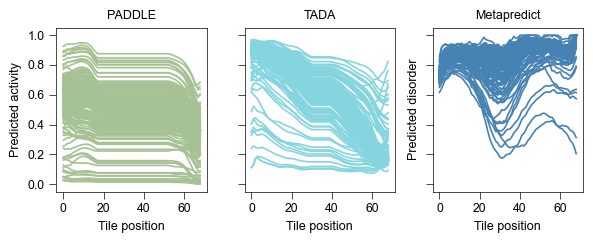

In [8]:
fig, axes = plt.subplots(ncols=3,figsize=(6,2.5),sharey=True)
for _,row in merged_df.iterrows():
    axes[0].plot(row['PADDLE_zscore_scaled'], label='PADDLE',color='#a6c194')
    axes[0].set_xlabel('Tile position')
    axes[0].set_title('PADDLE')
    axes[0].set_ylabel('Predicted activity')

    axes[1].plot(row['y_test_hat_scaled'], label='TADA',color='#85d5e0')
    axes[1].set_xlabel('Tile position')
    axes[1].set_title('TADA')

    axes[2].plot(row['disorder_predictions'], label='Metapredict',color='steelblue')
    axes[2].set_xlabel('Tile position')
    axes[2].set_ylabel('Predicted disorder')
    axes[2].set_title('Metapredict')
plt.tight_layout()

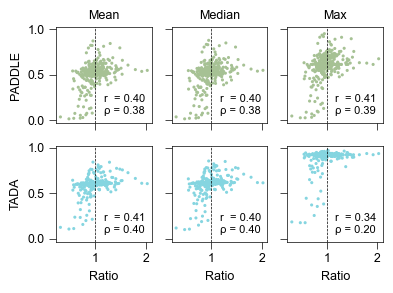

In [9]:
y_vars = ['PADDLE_mean', 'PADDLE_median', 'PADDLE_max','TADA_mean', 'TADA_median', 'TADA_max',]

fig, axes = plt.subplots(ncols=3,nrows=2,figsize=(4,3),sharex=True,sharey=True)
params = dict(s=5,edgecolor='None')
for idx, y in enumerate(y_vars):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    if row == 0:
        color = '#a6c194'
    else:
        color = '#85d5e0'
    sns.scatterplot(data=merged_df, x='ratio', y=y, ax=ax, color=color,**params)

    x_vals = merged_df['ratio']
    y_vals = merged_df[y]
    pearson_corr, _ = pearsonr(x_vals, y_vals)
    spearman_corr, _ = spearmanr(x_vals, y_vals)
    
    ax.text(0.5, 0.3,
            f"r  = {pearson_corr:.2f}\nρ = {spearman_corr:.2f}",
            transform=ax.transAxes,
            verticalalignment='top',
            fontsize=8)
    
axes[0,0].set_title('Mean')
axes[0,1].set_title('Median')
axes[0,2].set_title('Max')

axes[0,0].set_ylabel('PADDLE')
axes[1,0].set_ylabel('TADA')
axes[1,0].set_xlabel('Ratio')
axes[1,1].set_xlabel('Ratio')
axes[1,2].set_xlabel('Ratio')

axes[0,0].axvline(x=1,ymin=0,ymax=1,color='black',linewidth=0.5,linestyle='--')
axes[0,1].axvline(x=1,ymin=0,ymax=1,color='black',linewidth=0.5,linestyle='--')
axes[0,2].axvline(x=1,ymin=0,ymax=1,color='black',linewidth=0.5,linestyle='--')
axes[1,0].axvline(x=1,ymin=0,ymax=1,color='black',linewidth=0.5,linestyle='--')
axes[1,1].axvline(x=1,ymin=0,ymax=1,color='black',linewidth=0.5,linestyle='--')
axes[1,2].axvline(x=1,ymin=0,ymax=1,color='black',linewidth=0.5,linestyle='--')
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-ratio_vs_predictor.svg',**FIG_PARAMS)

In [10]:
columns_to_correlate = ['PADDLE_mean','PADDLE_median', 'PADDLE_max',
                        'TADA_mean', 'TADA_median','TADA_max']
results = []
for col in columns_to_correlate:
    valid = merged_df[['ratio', col]].dropna()
    x = valid['ratio']
    y = valid[col]
    
    pearson_r, _ = pearsonr(x, y)
    spearman_r, _ = spearmanr(x, y)
    
    results.append({
        'column': col,
        'pearson_r': pearson_r,
        'spearman_r': spearman_r})

correlation_df = pd.DataFrame(results).set_index('column')

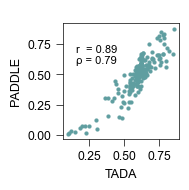

In [11]:
plt.figure(figsize=(1.5,1.5))
g = sns.scatterplot(data=merged_df,x='TADA_median',y='PADDLE_median',s=7.5, edgecolor=None, color='cadetblue')
g.set(xlabel='TADA',ylabel='PADDLE')

pearson_corr, _ = pearsonr(merged_df['TADA_median'], merged_df['PADDLE_median'])
spearman_corr, _ = spearmanr(merged_df['TADA_median'], merged_df['PADDLE_median'])

g.text(-2.25,0.75,
        f"r  = {pearson_corr:.2f}\nρ = {spearman_corr:.2f}",
        transform=ax.transAxes,
        fontsize=8);

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-tada_vs_paddle.svg',**FIG_PARAMS)